Language dataset: 96 rows, 8 languages
AI topic dataset: 60 rows, 5 topics

Language growth (2023-Q3 to 2026-Q2):
language
typescript    447.1%
python        284.0%
rust          233.8%
go            139.0%
javascript     80.9%
cpp            38.3%
java           12.0%
csharp         12.0%
dtype: object


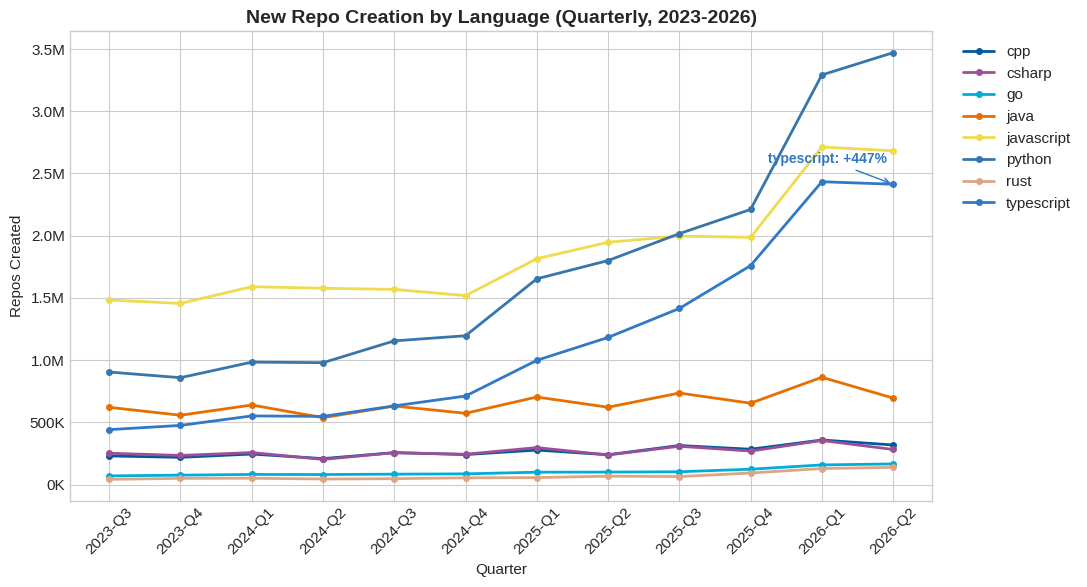

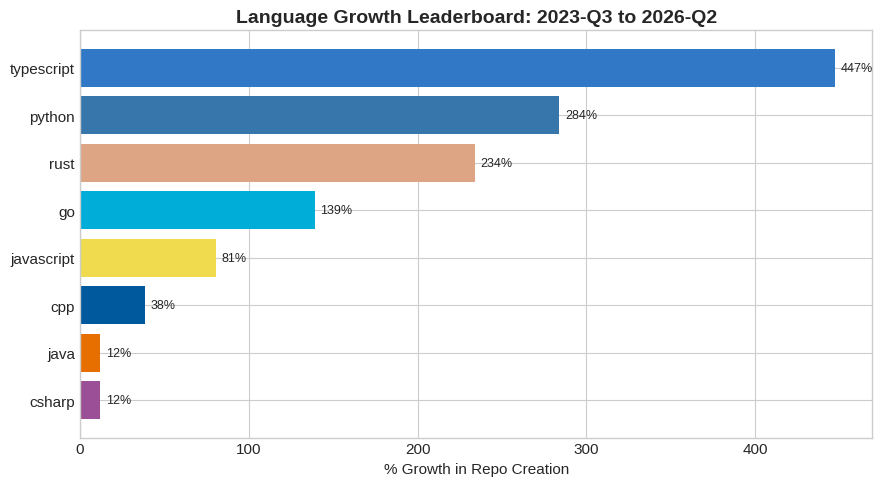


AI topic growth multiple (2023-Q3 to 2026-Q2):
topic
ai-agents        571.1x
rag               56.1x
llm               30.4x
generative-ai     11.6x
chatbot            5.0x
dtype: object


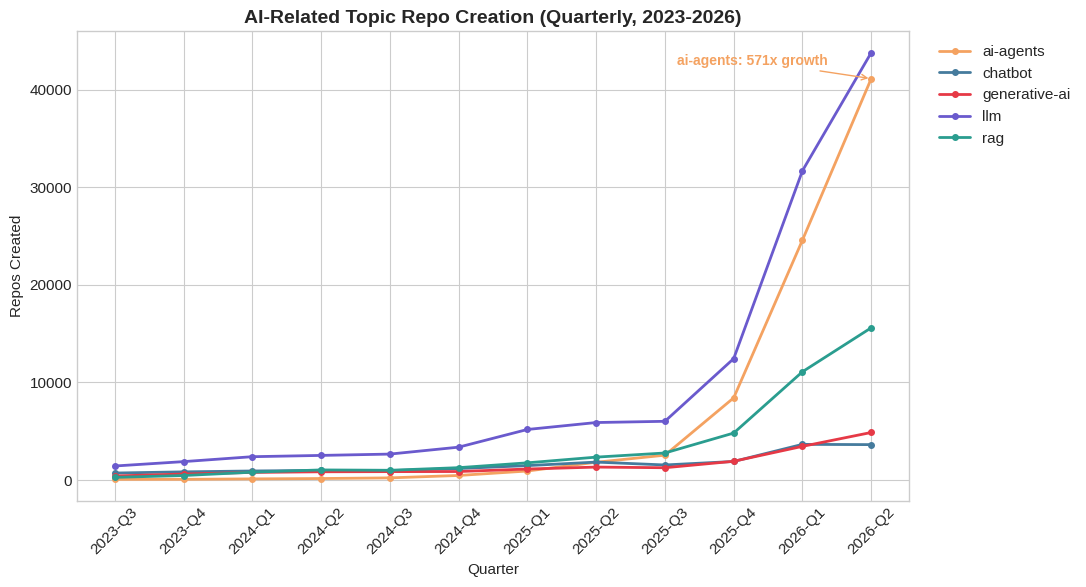

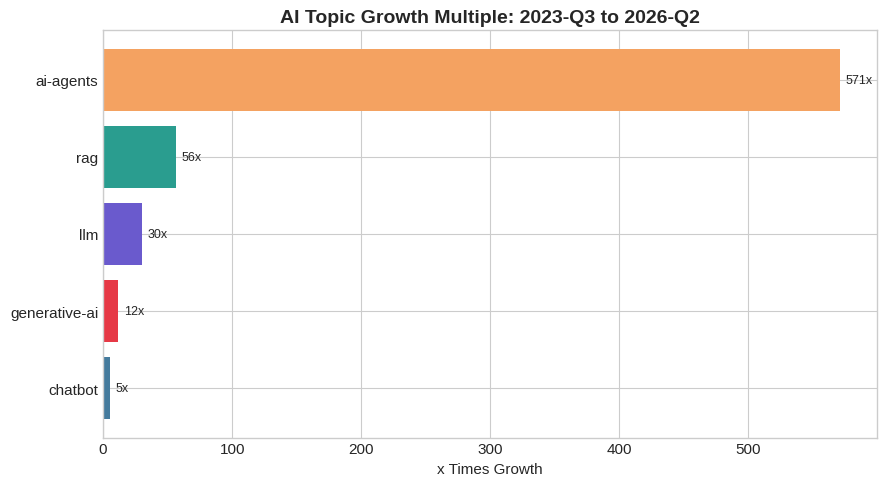

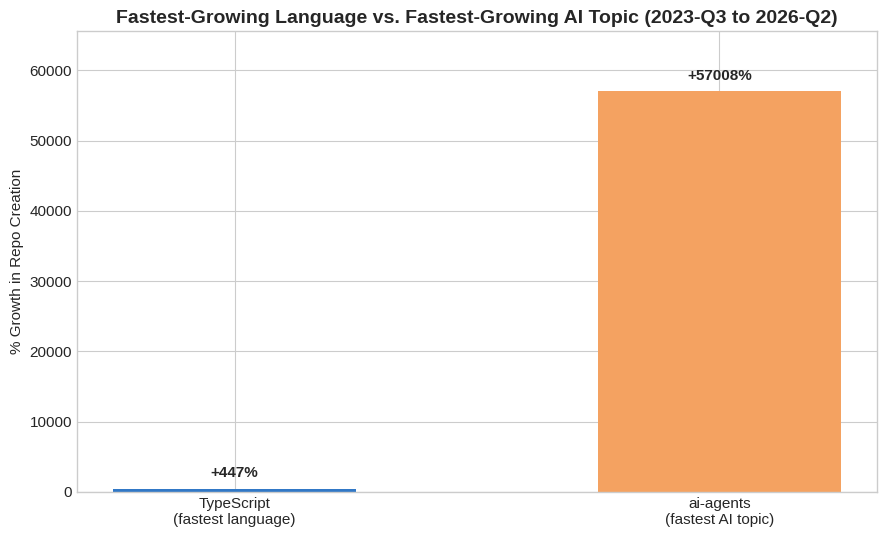


KEY FINDINGS
- TypeScript grew 447% since 2023 (fastest language)
- ai-agents grew 571x since 2023 (fastest AI topic)


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from io import StringIO

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"

PALETTE = {
    "python": "#3776AB", "javascript": "#F0DB4F", "typescript": "#3178C6",
    "go": "#00ADD8", "rust": "#DEA584", "java": "#E76F00",
    "cpp": "#00599C", "csharp": "#9B4F96",
    "llm": "#6A5ACD", "generative-ai": "#E63946", "rag": "#2A9D8F",
    "ai-agents": "#F4A261", "chatbot": "#457B9D",
}
QUARTER_ORDER = ["2023-Q3","2023-Q4","2024-Q1","2024-Q2","2024-Q3","2024-Q4",
                  "2025-Q1","2025-Q2","2025-Q3","2025-Q4","2026-Q1","2026-Q2"]

# ---------------- EMBEDDED DATA (no upload needed) ----------------

LANGUAGE_CSV = """language,quarter,start_date,end_date,repo_count
cpp,2023-Q3,2023-09-01,2023-11-30,229646
cpp,2023-Q4,2023-12-01,2024-02-29,218490
cpp,2024-Q1,2024-03-01,2024-05-31,244842
cpp,2024-Q2,2024-06-01,2024-08-31,208034
cpp,2024-Q3,2024-09-01,2024-11-30,256464
cpp,2024-Q4,2024-12-01,2025-02-28,240620
cpp,2025-Q1,2025-03-01,2025-05-31,276772
cpp,2025-Q2,2025-06-01,2025-08-31,239370
cpp,2025-Q3,2025-09-01,2025-11-30,313501
cpp,2025-Q4,2025-12-01,2026-02-28,283327
cpp,2026-Q1,2026-03-01,2026-05-31,357826
cpp,2026-Q2,2026-06-01,2026-08-29,317623
csharp,2023-Q3,2023-09-01,2023-11-30,251450
csharp,2023-Q4,2023-12-01,2024-02-29,233528
csharp,2024-Q1,2024-03-01,2024-05-31,256661
csharp,2024-Q2,2024-06-01,2024-08-31,202027
csharp,2024-Q3,2024-09-01,2024-11-30,255277
csharp,2024-Q4,2024-12-01,2025-02-28,243323
csharp,2025-Q1,2025-03-01,2025-05-31,296635
csharp,2025-Q2,2025-06-01,2025-08-31,237451
csharp,2025-Q3,2025-09-01,2025-11-30,307471
csharp,2025-Q4,2025-12-01,2026-02-28,268835
csharp,2026-Q1,2026-03-01,2026-05-31,354071
csharp,2026-Q2,2026-06-01,2026-08-29,281574
go,2023-Q3,2023-09-01,2023-11-30,69269
go,2023-Q4,2023-12-01,2024-02-29,75139
go,2024-Q1,2024-03-01,2024-05-31,80896
go,2024-Q2,2024-06-01,2024-08-31,80168
go,2024-Q3,2024-09-01,2024-11-30,83178
go,2024-Q4,2024-12-01,2025-02-28,85719
go,2025-Q1,2025-03-01,2025-05-31,99072
go,2025-Q2,2025-06-01,2025-08-31,99774
go,2025-Q3,2025-09-01,2025-11-30,102494
go,2025-Q4,2025-12-01,2026-02-28,122940
go,2026-Q1,2026-03-01,2026-05-31,157385
go,2026-Q2,2026-06-01,2026-08-29,165548
java,2023-Q3,2023-09-01,2023-11-30,620312
java,2023-Q4,2023-12-01,2024-02-29,556711
java,2024-Q1,2024-03-01,2024-05-31,639065
java,2024-Q2,2024-06-01,2024-08-31,537032
java,2024-Q3,2024-09-01,2024-11-30,630766
java,2024-Q4,2024-12-01,2025-02-28,572540
java,2025-Q1,2025-03-01,2025-05-31,703243
java,2025-Q2,2025-06-01,2025-08-31,621228
java,2025-Q3,2025-09-01,2025-11-30,735256
java,2025-Q4,2025-12-01,2026-02-28,653576
java,2026-Q1,2026-03-01,2026-05-31,862043
java,2026-Q2,2026-06-01,2026-08-29,694659
javascript,2023-Q3,2023-09-01,2023-11-30,1482947
javascript,2023-Q4,2023-12-01,2024-02-29,1455564
javascript,2024-Q1,2024-03-01,2024-05-31,1589786
javascript,2024-Q2,2024-06-01,2024-08-31,1577578
javascript,2024-Q3,2024-09-01,2024-11-30,1568285
javascript,2024-Q4,2024-12-01,2025-02-28,1518191
javascript,2025-Q1,2025-03-01,2025-05-31,1815050
javascript,2025-Q2,2025-06-01,2025-08-31,1947116
javascript,2025-Q3,2025-09-01,2025-11-30,1996831
javascript,2025-Q4,2025-12-01,2026-02-28,1986659
javascript,2026-Q1,2026-03-01,2026-05-31,2712743
javascript,2026-Q2,2026-06-01,2026-08-29,2682530
python,2023-Q3,2023-09-01,2023-11-30,904006
python,2023-Q4,2023-12-01,2024-02-29,858573
python,2024-Q1,2024-03-01,2024-05-31,983777
python,2024-Q2,2024-06-01,2024-08-31,979243
python,2024-Q3,2024-09-01,2024-11-30,1154531
python,2024-Q4,2024-12-01,2025-02-28,1195836
python,2025-Q1,2025-03-01,2025-05-31,1653430
python,2025-Q2,2025-06-01,2025-08-31,1800248
python,2025-Q3,2025-09-01,2025-11-30,2016487
python,2025-Q4,2025-12-01,2026-02-28,2211069
python,2026-Q1,2026-03-01,2026-05-31,3291924
python,2026-Q2,2026-06-01,2026-08-29,3471169
rust,2023-Q3,2023-09-01,2023-11-30,41350
rust,2023-Q4,2023-12-01,2024-02-29,49342
rust,2024-Q1,2024-03-01,2024-05-31,50448
rust,2024-Q2,2024-06-01,2024-08-31,44039
rust,2024-Q3,2024-09-01,2024-11-30,46785
rust,2024-Q4,2024-12-01,2025-02-28,53644
rust,2025-Q1,2025-03-01,2025-05-31,55509
rust,2025-Q2,2025-06-01,2025-08-31,66978
rust,2025-Q3,2025-09-01,2025-11-30,63750
rust,2025-Q4,2025-12-01,2026-02-28,92338
rust,2026-Q1,2026-03-01,2026-05-31,128296
rust,2026-Q2,2026-06-01,2026-08-29,138035
typescript,2023-Q3,2023-09-01,2023-11-30,441145
typescript,2023-Q4,2023-12-01,2024-02-29,474999
typescript,2024-Q1,2024-03-01,2024-05-31,551420
typescript,2024-Q2,2024-06-01,2024-08-31,547609
typescript,2024-Q3,2024-09-01,2024-11-30,631947
typescript,2024-Q4,2024-12-01,2025-02-28,711064
typescript,2025-Q1,2025-03-01,2025-05-31,998208
typescript,2025-Q2,2025-06-01,2025-08-31,1182231
typescript,2025-Q3,2025-09-01,2025-11-30,1415070
typescript,2025-Q4,2025-12-01,2026-02-28,1759374
typescript,2026-Q1,2026-03-01,2026-05-31,2433761
typescript,2026-Q2,2026-06-01,2026-08-29,2413458
"""

AI_TOPIC_CSV = """topic,quarter,start_date,end_date,repo_count
llm,2023-Q3,2023-09-01,2023-11-30,1440
llm,2023-Q4,2023-12-01,2024-02-29,1889
llm,2024-Q1,2024-03-01,2024-05-31,2394
llm,2024-Q2,2024-06-01,2024-08-31,2525
llm,2024-Q3,2024-09-01,2024-11-30,2661
llm,2024-Q4,2024-12-01,2025-02-28,3370
llm,2025-Q1,2025-03-01,2025-05-31,5182
llm,2025-Q2,2025-06-01,2025-08-31,5893
llm,2025-Q3,2025-09-01,2025-11-30,6019
llm,2025-Q4,2025-12-01,2026-02-28,12441
llm,2026-Q1,2026-03-01,2026-05-31,31685
llm,2026-Q2,2026-06-01,2026-08-29,43777
generative-ai,2023-Q3,2023-09-01,2023-11-30,420
generative-ai,2023-Q4,2023-12-01,2024-02-29,619
generative-ai,2024-Q1,2024-03-01,2024-05-31,782
generative-ai,2024-Q2,2024-06-01,2024-08-31,849
generative-ai,2024-Q3,2024-09-01,2024-11-30,864
generative-ai,2024-Q4,2024-12-01,2025-02-28,875
generative-ai,2025-Q1,2025-03-01,2025-05-31,1131
generative-ai,2025-Q2,2025-06-01,2025-08-31,1330
generative-ai,2025-Q3,2025-09-01,2025-11-30,1263
generative-ai,2025-Q4,2025-12-01,2026-02-28,1924
generative-ai,2026-Q1,2026-03-01,2026-05-31,3454
generative-ai,2026-Q2,2026-06-01,2026-08-29,4875
rag,2023-Q3,2023-09-01,2023-11-30,278
rag,2023-Q4,2023-12-01,2024-02-29,464
rag,2024-Q1,2024-03-01,2024-05-31,807
rag,2024-Q2,2024-06-01,2024-08-31,1038
rag,2024-Q3,2024-09-01,2024-11-30,1002
rag,2024-Q4,2024-12-01,2025-02-28,1270
rag,2025-Q1,2025-03-01,2025-05-31,1766
rag,2025-Q2,2025-06-01,2025-08-31,2349
rag,2025-Q3,2025-09-01,2025-11-30,2773
rag,2025-Q4,2025-12-01,2026-02-28,4816
rag,2026-Q1,2026-03-01,2026-05-31,11095
rag,2026-Q2,2026-06-01,2026-08-29,15599
ai-agents,2023-Q3,2023-09-01,2023-11-30,72
ai-agents,2023-Q4,2023-12-01,2024-02-29,76
ai-agents,2024-Q1,2024-03-01,2024-05-31,121
ai-agents,2024-Q2,2024-06-01,2024-08-31,157
ai-agents,2024-Q3,2024-09-01,2024-11-30,224
ai-agents,2024-Q4,2024-12-01,2025-02-28,471
ai-agents,2025-Q1,2025-03-01,2025-05-31,927
ai-agents,2025-Q2,2025-06-01,2025-08-31,1825
ai-agents,2025-Q3,2025-09-01,2025-11-30,2549
ai-agents,2025-Q4,2025-12-01,2026-02-28,8421
ai-agents,2026-Q1,2026-03-01,2026-05-31,24581
ai-agents,2026-Q2,2026-06-01,2026-08-29,41118
chatbot,2023-Q3,2023-09-01,2023-11-30,720
chatbot,2023-Q4,2023-12-01,2024-02-29,841
chatbot,2024-Q1,2024-03-01,2024-05-31,930
chatbot,2024-Q2,2024-06-01,2024-08-31,993
chatbot,2024-Q3,2024-09-01,2024-11-30,966
chatbot,2024-Q4,2024-12-01,2025-02-28,1183
chatbot,2025-Q1,2025-03-01,2025-05-31,1480
chatbot,2025-Q2,2025-06-01,2025-08-31,1841
chatbot,2025-Q3,2025-09-01,2025-11-30,1547
chatbot,2025-Q4,2025-12-01,2026-02-28,1905
chatbot,2026-Q1,2026-03-01,2026-05-31,3658
chatbot,2026-Q2,2026-06-01,2026-08-29,3630
"""

lang = pd.read_csv(StringIO(LANGUAGE_CSV))
topic = pd.read_csv(StringIO(AI_TOPIC_CSV))
lang["quarter"] = pd.Categorical(lang["quarter"], categories=QUARTER_ORDER, ordered=True)
topic["quarter"] = pd.Categorical(topic["quarter"], categories=QUARTER_ORDER, ordered=True)
lang = lang.sort_values(["language", "quarter"]).reset_index(drop=True)
topic = topic.sort_values(["topic", "quarter"]).reset_index(drop=True)

print(f"Language dataset: {lang.shape[0]} rows, {lang['language'].nunique()} languages")
print(f"AI topic dataset: {topic.shape[0]} rows, {topic['topic'].nunique()} topics")

# ---------------- LANGUAGE ANALYSIS ----------------

lang_pivot = lang.pivot(index="quarter", columns="language", values="repo_count")
first_q, last_q = QUARTER_ORDER[0], QUARTER_ORDER[-1]
overall_growth = ((lang_pivot.loc[last_q] - lang_pivot.loc[first_q]) / lang_pivot.loc[first_q] * 100).sort_values(ascending=False)

print("\nLanguage growth (2023-Q3 to 2026-Q2):")
print(overall_growth.round(1).astype(str) + "%")

fig, ax = plt.subplots(figsize=(11, 6))
for language in lang_pivot.columns:
    ax.plot(lang_pivot.index, lang_pivot[language], marker="o", markersize=4,
            linewidth=2, label=language, color=PALETTE.get(language))
ax.set_title("New Repo Creation by Language (Quarterly, 2023-2026)")
ax.set_xlabel("Quarter")
ax.set_ylabel("Repos Created")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x/1e3:.0f}K"))
plt.xticks(rotation=45)
top_lang = overall_growth.index[0]
ax.annotate(f"{top_lang}: +{overall_growth.iloc[0]:.0f}%",
            xy=(QUARTER_ORDER[-1], lang_pivot[top_lang].iloc[-1]),
            xytext=(-90, 15), textcoords="offset points",
            fontsize=10, fontweight="bold", color=PALETTE.get(top_lang),
            arrowprops=dict(arrowstyle="->", color=PALETTE.get(top_lang)))
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(overall_growth.index[::-1], overall_growth.values[::-1],
                color=[PALETTE.get(l, "#888888") for l in overall_growth.index[::-1]])
ax.set_title(f"Language Growth Leaderboard: {first_q} to {last_q}")
ax.set_xlabel("% Growth in Repo Creation")
ax.bar_label(bars, fmt="%.0f%%", padding=4, fontsize=9)
plt.tight_layout()
plt.show()

# ---------------- AI TOPIC ANALYSIS ----------------

topic_pivot = topic.pivot(index="quarter", columns="topic", values="repo_count")
growth_t = ((topic_pivot.loc[last_q] - topic_pivot.loc[first_q]) / topic_pivot.loc[first_q] * 100).sort_values(ascending=False)
multiple_t = (topic_pivot.loc[last_q] / topic_pivot.loc[first_q]).sort_values(ascending=False)

print("\nAI topic growth multiple (2023-Q3 to 2026-Q2):")
print(multiple_t.round(1).astype(str) + "x")

fig, ax = plt.subplots(figsize=(11, 6))
for t in topic_pivot.columns:
    ax.plot(topic_pivot.index, topic_pivot[t], marker="o", markersize=4,
            linewidth=2, label=t, color=PALETTE.get(t))
ax.set_title("AI-Related Topic Repo Creation (Quarterly, 2023-2026)")
ax.set_xlabel("Quarter")
ax.set_ylabel("Repos Created")
plt.xticks(rotation=45)
top_topic = multiple_t.index[0]
ax.annotate(f"{top_topic}: {multiple_t.iloc[0]:.0f}x growth",
            xy=(QUARTER_ORDER[-1], topic_pivot[top_topic].iloc[-1]),
            xytext=(-140, 10), textcoords="offset points",
            fontsize=10, fontweight="bold", color=PALETTE.get(top_topic),
            arrowprops=dict(arrowstyle="->", color=PALETTE.get(top_topic)))
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(multiple_t.index[::-1], multiple_t.values[::-1],
                color=[PALETTE.get(t, "#888888") for t in multiple_t.index[::-1]])
ax.set_title(f"AI Topic Growth Multiple: {first_q} to {last_q}")
ax.set_xlabel("x Times Growth")
ax.bar_label(bars, fmt="%.0fx", padding=4, fontsize=9)
plt.tight_layout()
plt.show()

# ---------------- COMPARISON ----------------

fig, ax = plt.subplots(figsize=(9, 5.5))
compare = pd.Series({
    "TypeScript\n(fastest language)": overall_growth.iloc[0],
    "ai-agents\n(fastest AI topic)": growth_t.iloc[0],
})
bars = ax.bar(compare.index, compare.values, color=["#3178C6", "#F4A261"], width=0.5)
ax.set_title(f"Fastest-Growing Language vs. Fastest-Growing AI Topic ({first_q} to {last_q})")
ax.set_ylabel("% Growth in Repo Creation")
ax.bar_label(bars, fmt="+%.0f%%", padding=6, fontsize=11, fontweight="bold")
ax.margins(y=0.15)
plt.tight_layout()
plt.show()

print("\nKEY FINDINGS")
print(f"- TypeScript grew {overall_growth.iloc[0]:.0f}% since 2023 (fastest language)")
print(f"- ai-agents grew {multiple_t.iloc[0]:.0f}x since 2023 (fastest AI topic)")